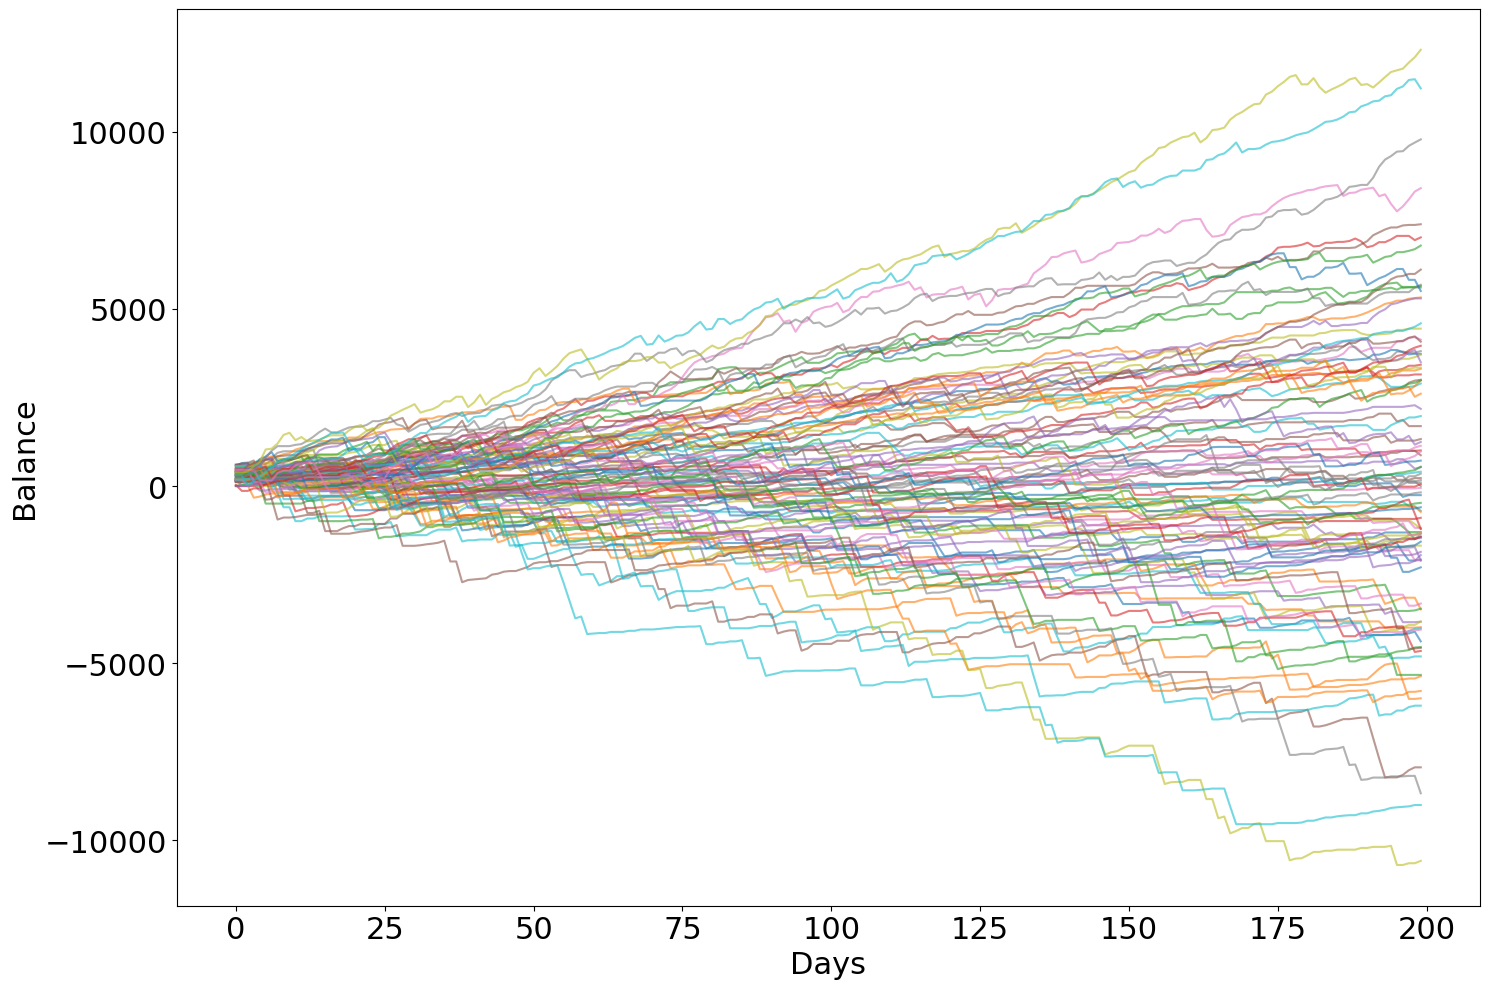

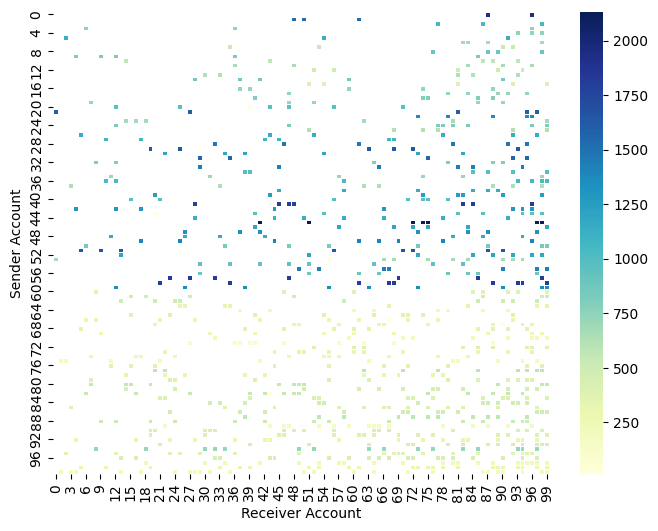


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.96e+01 time=9.07e-04
* iter=1 time=1.81e-03 obj=5.09e+03 |delta(obj)|/obj=9.80e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 1.10e+00] lns_iter=3 
* iter=2 time=2.39e-03 obj=4.48e+03 |delta(obj)|/obj=1.37e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 5.07e+01] lns_iter=4 
* iter=3 time=9.24e-03 obj=4.22e+03 |de

/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expecte

In [1]:
from workflow.internal import *

# Load dataset (the user will pass the name)
df, name, dimension = load_dataset()

# Extract time series
extract_timeseries(df)

# Normalise time series
Y_norm = normalization(df, name)

# Create transaction matrix
adj_matrix = adjaceny_matrix(Y_norm, name, dimension)

# Run SQUIC_fit
W_matrices, _ = squic_fit_computation(Y_norm, name, dimension, adj_matrix)

# Use the extracted W for clustering
dict_cluster = clustering(W_matrices)

# Report internal metrics on the clustering
int_metrics = internal_metrics(dict_cluster, W_matrices)

In [2]:
visualize_metrics(int_metrics)

For rho = 0.9
    louvain : {'ncut': 1.0, 'rcut': 0.11, 'modularity': 0.38, 'CC': 29, 'nCluster': 32}
    dbscan : {'ncut': 0.0, 'rcut': 0.0, 'modularity': -0.0, 'CC': 29, 'nCluster': 1}
    spectral : {'ncut': 0.1, 'rcut': 0.01, 'modularity': 0.37, 'CC': 29, 'nCluster': 2}


For rho = 0.5
    louvain : {'ncut': 0.6, 'rcut': 0.19, 'modularity': 0.54, 'CC': 2, 'nCluster': 6}
    dbscan : {'ncut': 0.0, 'rcut': 0.0, 'modularity': 0.0, 'CC': 2, 'nCluster': 1}
    spectral : {'ncut': 0.0, 'rcut': 0.0, 'modularity': 0.47, 'CC': 2, 'nCluster': 2}


For rho = 0.2
    louvain : {'ncut': 1.21, 'rcut': 0.98, 'modularity': 0.58, 'CC': 1, 'nCluster': 5}
    dbscan : {'ncut': 80.95, 'rcut': 84.61, 'modularity': -0.01, 'CC': 1, 'nCluster': 81}
    spectral : {'ncut': 0.05, 'rcut': 0.04, 'modularity': 0.44, 'CC': 1, 'nCluster': 2}




In [3]:
# Visualise with cosmograph
widget_dict = visualize_graph(W_matrices, dict_cluster, name, dimension)

In [9]:
widget_dict[0.2]["louvain"]

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [7]:
widget_dict[0.2]["spectral"]

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [8]:
widget_dict[0.2]["dbscan"]

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…